In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import math
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#from sklearn.model_selection import test_train_split
#from sklearn.ensemble import RandomForestCalssifier
#from sklearn.impute import SimpleImputer
#from sklearn.metrics import accuracy_score, classification_report

In [124]:
# USER INPUTS
verbose_flag = 0
sql_filename = "/home/mike/GitHub/ExternalData/YahooFinanceAnalysis/TestData_Do_Not_Delete/BaseDatasets/SP500_data_06062026_not_verified.db"

In [ ]:
# FIND ALL UNIQUE SECTORS
#select_query = """
#    SELECT DISTINCT Sector 
#    FROM portfolio_data;
#"""
select_query = """
    SELECT Sector, COUNT(*) AS Count 
    FROM portfolio_data
    GROUP BY Sector;
"""

conn = sqlite3.connect(sql_filename)
cursor = conn.cursor()
unique_sector_db = pd.read_sql_query(select_query, conn)
conn.close()

print(f"unique_sector_db is {unique_sector_db}\n")
# drop count from dataframe
unique_sector_db = unique_sector_db["Sector"]

# drop NaNs from dataframe
unique_sector_db = unique_sector_db.dropna()

# convert dataframe to list
unique_sector_list = unique_sector_db.values.tolist()
print(f"unique_sector_list is {unique_sector_list}")


In [ ]:
# 1. Fetch ALL sector averages at the same time using GROUP BY
select_query = """
    SELECT Sector, Price_To_Sales, Price_To_Earnings, Price_To_Book, Cash_To_Debt_Over_Market_Cap, Operating_Margin
    FROM portfolio_data 
    WHERE Sector IS NOT NULL
"""

conn = sqlite3.connect(sql_filename)
metrics_df = pd.read_sql_query(select_query, conn)
conn.close()

# drop NaNs from dataframe 
#  SQL query captures this now
metrics_df = metrics_df.dropna()

#print(f"metrics_df is {metrics_df}")

# Set Sector as the index so it maps perfectly to the chart axes
metrics_df.set_index('Sector', inplace=True)
metrics_df = metrics_df.dropna()

# Compute Mean and Std dataframes
means_df = metrics_df.groupby('Sector').mean()
stds_df = metrics_df.groupby('Sector').std()

print(f"means_df is \n {means_df}\n \n----------------\n")
print(f"stds_df is \n {stds_df}")

In [120]:
# Winsorize / Clip Outliers
# Cap extreme values 
ll = 0.1
ul = 0.9
quantiles_df = metrics_df.quantile([ll, ul])
for col in metrics_df.columns:
    lower_bound = quantiles_df.loc[ll, col]
    upper_bound = quantiles_df.loc[ul, col]
    metrics_df[col] = metrics_df[col].clip(lower_bound, upper_bound)

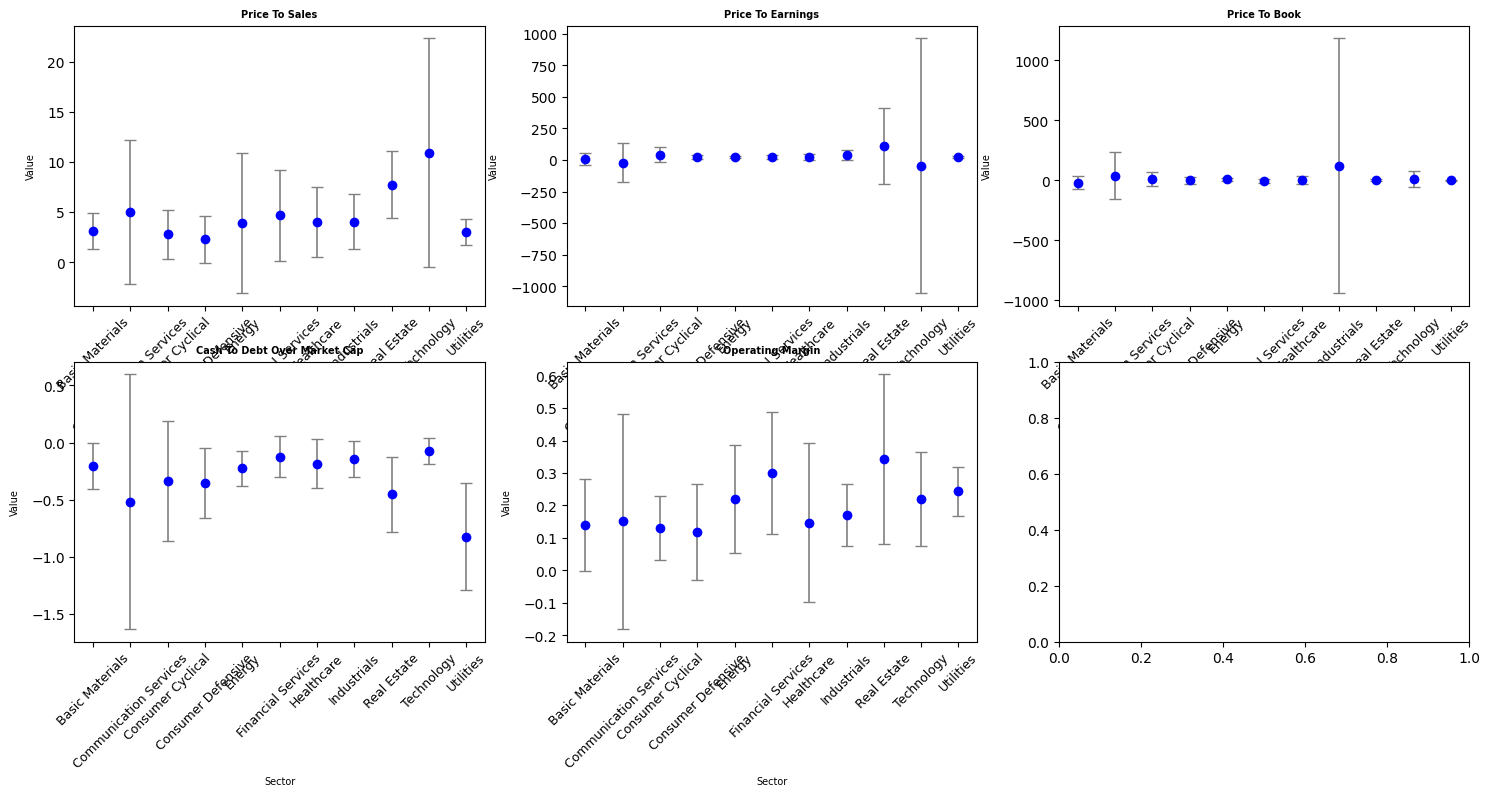

In [121]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8), sharex=False)
fs = 7
axes = axes.flatten() # Flatten the 2D grid into an easily iterable 1D array

for ii, metric_ii in enumerate(means_df.columns):
    axes[ii].errorbar(
        means_df.index,
        means_df[metric_ii],
        yerr = stds_df[metric_ii],
        fmt='o',            
        capsize=4,     
        color=[0, 0, 1],   
        ecolor = [0.5, 0.5, 0.5],
        markersize=6,       
        linewidth=1.2,
    )
    # get value at 75% percentile for std to use for y limits
    title_str = metric_ii.replace('_', ' ')
    axes[ii].set_title(title_str, fontsize=fs, fontweight='bold')
    
    axes[ii].set_xlabel('Sector', fontsize=fs)#, labelpad=8)
    axes[ii].set_ylabel('Value', fontsize=fs, labelpad=8)
    axes[ii].tick_params(axis='x', rotation=45, labelsize=9)

In [122]:
if verbose_flag:
    cc = 0
    for sec_ii in metrics_df.keys():
        print(f"{cc} : {sec_ii}")
        cc += 1
    
    [print(ii) for ii in metrics_df.columns.tolist()] 
    
    [print(ii) for ii in means_df.index.tolist()]

'\ncc = 0\nfor sec_ii in metrics_df.keys():\n    print(f"{cc} : {sec_ii}")\n    cc += 1\n\n[print(ii) for ii in metrics_df.columns.tolist()] \n\n[print(ii) for ii in means_df.index.tolist()]\n'

In [135]:
train_frac = 0.7
test_frac = 0.3
val_frac = 0
num_terminal_nodes = len(means_df)+1
num_estimators = math.factorial(len(means_df.columns))
#print(f"{num_estimators}")

feat_data = metrics_df.values  
sect_data = metrics_df.index.values

# Split into train, test, and experiment/validate groups
feat_data_train, feat_data_val, sect_data_train, sect_data_val = train_test_split(feat_data, sect_data, test_size=test_frac, random_state=42, stratify=sect_data)
#feat_data_train, feat_data_temp, seat_data_train, sect_data_temp = train_test_split(feat_data, sect_data, test_size=1/3, random_state=42, stratify=sect_data)
#feat_data_test, feat_data_val, seat_data_test, sect_data_val = train_test_split(feat_data_temp, sect_data_temp, test_size=1/3, random_state=42, stratify=sect_data_temp)

if verbose_flag:
    print(f"training size:   {feat_data_train.shape[0]}")
    print(f"testing size:    {feat_data_train.shape[0]}")
    print(f"validation size: {feat_data_train.shape[0]}\n")

# Instantiate Random Forest
rand_forest_model = RandomForestClassifier(
    n_estimators=num_estimators, 
    max_leaf_nodes=num_terminal_nodes, 
    max_depth = 12,
    min_samples_leaf = 5,
    random_state=42
)

# Train
rand_forest_model.fit(feat_data_train, sect_data_train)

# Predict
sect_data_pred = rand_forest_model.predict(feat_data_val)
print(f"Accuracy: {accuracy_score(sect_data_val, sect_data_pred):.4f}")
print(classification_report(sect_data_val, sect_data_pred))

Accuracy: 0.3776
                        precision    recall  f1-score   support

       Basic Materials       0.00      0.00      0.00         6
Communication Services       0.00      0.00      0.00         7
     Consumer Cyclical       0.29      0.25      0.27        16
    Consumer Defensive       0.40      0.20      0.27        10
                Energy       0.00      0.00      0.00         6
    Financial Services       0.33      0.38      0.36        13
            Healthcare       0.33      0.22      0.27        18
           Industrials       0.33      0.65      0.43        23
           Real Estate       0.70      0.70      0.70        10
            Technology       0.38      0.36      0.37        25
             Utilities       0.47      0.89      0.62         9

              accuracy                           0.38       143
             macro avg       0.29      0.33      0.30       143
          weighted avg       0.33      0.38      0.34       143



/home/mike/yes/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mike/yes/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mike/yes/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# ================ BELOW IS SUPPLEMENTAL : SQL TESTING ==============================

In [ ]:
# GET MEAN AND STD OF EACH METRIC
avg_metric = []
std_metric = []
for sector_ii in unique_sector_list: 
    #print(sector_ii)   
    select_compute_query = f"""
        SELECT 
            AVG(Price_To_Sales) AS Mean_P_S, 
            AVG(Price_To_Earnings) AS Mean_P_E, 
            AVG(Price_To_Book) AS Mean_P_B, 
            AVG(Cash_To_Debt_Over_Market_Cap) AS Mean_Cash_Debt, 
            AVG(Operating_Margin) AS Mean_Op_Margin
        FROM portfolio_data 
        WHERE Sector = "{sector_ii}"
    """
    #print(select_compute_query)
    conn = sqlite3.connect(sql_filename)
    cursor = conn.cursor()
    #cursor = conn.cursor()
    cursor.execute(select_compute_query)
    unique_sector_metrics_ii = cursor.fetchall()
    #unique_sector_metrics_ii = pd.read_sql_query(select_compute_query, conn)
    conn.close()
    print(unique_sector_metrics_ii)
    #print(select_query)

In [ ]:
# 1. Fetch ALL sector averages at the same time using GROUP BY
select_compute_query = """
    SELECT 
        Sector,
        AVG(Price_To_Sales) AS Avg_Price_To_Sales, 
        STDDEV(Price_To_Sales) AS Std_Price_To_Sales,
        AVG(Price_To_Earnings) AS Price_To_Earnings, 
        STDDEV(Price_To_Earnings) AS Std_Price_To_Earnings, 
        AVG(Price_To_Book) AS Avg_Price_To_Book, 
        STDDEV(Price_To_Book) AS Std_Price_To_Book, 
        AVG(Cash_To_Debt_Over_Market_Cap) AS Avg_Cash_To_Debt, 
        STDDEV(Cash_To_Debt_Over_Market_Cap) AS Std_Cash_To_Debt, 
        AVG(Operating_Margin) AS Avg_Operating_Margin,
        STDEV(Operating_Margin) AS Std_Operating_Margin    
    FROM portfolio_data 
    WHERE Sector IS NOT NULL
    GROUP BY Sector;
"""

conn = sqlite3.connect(sql_filename)
metrics_df = pd.read_sql_query(select_compute_query, conn)
conn.close()

# Set Sector as the index so it maps perfectly to the chart axes
metrics_df.set_index('Sector', inplace=True)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=False)
axes = axes.flatten() # Flatten the 2D grid into an easily iterable 1D array

metrics_list = ['Avg_Price_To_Sales', 'Avg_Price_To_Earnings', 'Avg_Price_To_Book', 'Avg_Cash_To_Debt', 'Avg_Operating_Margin']
metrics_list_pp = ['Std_Price_To_Sales', 'Std_Price_To_Earnings', 'Std_Price_To_Book', 'Std_Cash_To_Debt', 'Std_Operating_Margin']

for ii, metric_ii in enumerate(metrics_list):
    # Sort the data so bars are clean and readable from highest to lowest
    metrics_df_ii = metrics_df[metric_ii]
    
    metrics_df_ii.errorbar(
        metric_ii, 
        metrics_df_ii, 
        yerr=metrics_df[metrics_list_pp[ii]], 
        fmt='o',        # 'o' creates a scatter point marker
        color='blue',   # Color of the points and lines
        ecolor='red',   # Color of the error bars specifically
        capsize=5,      # Width of the horizontal caps on error bars
        markersize=8    # Size of the scatter points
    )

# Hide the unused 6th subplot grid square
fig.delaxes(axes[5])

plt.suptitle("Cross-Sector Financial Metric Comparison", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()